# Lab 14 — PD, PI e PID na Frequência

**Módulo 03 · Semana 14 · Laboratório de Controle Automático (Ifes Guarapari)**

Neste laboratório você vai:
1. Projetar um **PD pelas fórmulas diretas** ($k_p$, $k_d$ + polo de filtragem) e compará-lo com o avanço — inclusive no **sinal de controle**;
2. Projetar um **PI** e observar a cauda lenta do integrador;
3. Projetar um **PID completo** (PD × PI) atendendo três requisitos;
4. Fechar o módulo com a **síntese na carta de Nichols-Black**.

Teoria de referência: `teoria_modulo3.md`, seção **§3.5** (figuras `m3_fig32` a `m3_fig36`).

In [1]:
# %% IMPORTS (rode esta célula primeiro)
!pip install --quiet control==0.10.2
import control as ct
import numpy as np
import matplotlib.pyplot as plt
import math
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True

def step(G, t):
    t, y = ct.step_response(G, t)
    return np.asarray(t), np.asarray(y)   # python-control 0.10.2: converte NamedSignal

def medir(T, t=None):
    # Mede Mp (%), tp, tr(0-100%) e ts(5%) da resposta ao degrau de T.
    if t is None: t = np.linspace(0, 50, 20000)
    t, y = step(T, t)
    yss = y[-1]
    Mp = 100*(y.max() - yss)/yss
    tp = t[np.argmax(y)]
    tr = t[np.argmax(y >= yss)]
    fora = np.where(np.abs(y - yss) > 0.05*abs(yss))[0]
    ts = t[fora[-1]] if len(fora) else 0.0
    return dict(Mp=Mp, tp=tp, tr=tr, ts=ts, yss=yss)

def mp(G, w):
    # Módulo (vezes) e fase (graus) de G em w (rad/s).
    mag, ph, _ = ct.frequency_response(G, np.atleast_1d(w))
    return np.asarray(mag).ravel(), np.degrees(np.asarray(ph).ravel())

def mf(G):
    return ct.feedback(G, 1)

print('python-control', ct.__version__)
def carta_nb(ax, xlim=(-270, -30), ylim=(-40, 30)):
    # Desenha a carta de Nichols-Black (grade de malha fechada) no eixo ax.
    fantasma = ct.tf([1e-6], [1, 1e-6])   # sistema fantasma só para gerar a grade
    ct.nichols_plot(fantasma, grid=True, ax=ax)
    for ln in ax.get_lines():
        if ln.get_label().startswith('sys'):
            ln.set_label('_nolegend_')
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xlabel('Fase de malha aberta (graus)')
    ax.set_ylabel('Módulo de malha aberta (dB)')

def nb_curve(G, w):
    # Curva de Nichols de G: fase enrolada em (-360, 0] e módulo em dB.
    m, p = mp(G, w)
    pw = np.mod(p, 360); pw[pw > 0] -= 360
    return pw, 20*np.log10(m)


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


python-control 0.10.2


## Parte 1 — PD pelas fórmulas diretas e o preço no atuador

Mesma planta do Lab 13 Parte 1: $G(s) = \dfrac{0{,}005}{s(s+0{,}05)}$, mesma meta: PM $= 40°$ em $\omega_c = 0{,}11$ rad/s.

**Fórmulas diretas do PD (§3.5.1):** $k_p = \dfrac{\cos\phi}{|G(j\omega_c)|}$, $\quad k_d = \dfrac{\mathrm{sen}\,\phi}{\omega_c\,|G(j\omega_c)|}$, com polo de filtragem em $-100\,\omega_c$ (custa só $-0{,}6°$).

O controlador projetado no exemplo da teoria é $C_{PD}(s) = \dfrac{2{,}7 + 7{,}6\,s}{s/110 + 1}$ — vamos verificá-lo e compará-lo com o **avanço** do Lab 13, $C_{AV}(s) = 2{,}1\,\dfrac{12s+1}{6{,}5s+1}$.

PD: ωc = 0.114, PM = 41.4° | sim: Mp = 30.1%, tr = 15.0 s


avanço: ωc = 0.115, PM = 40.8° | sim: Mp = 29.6%, tr = 15.5 s



PICO DO SINAL DE CONTROLE:  PD = 836.0   vs   avanço = 3.88
razão = 216× — o PD exige 216 vezes mais do atuador!


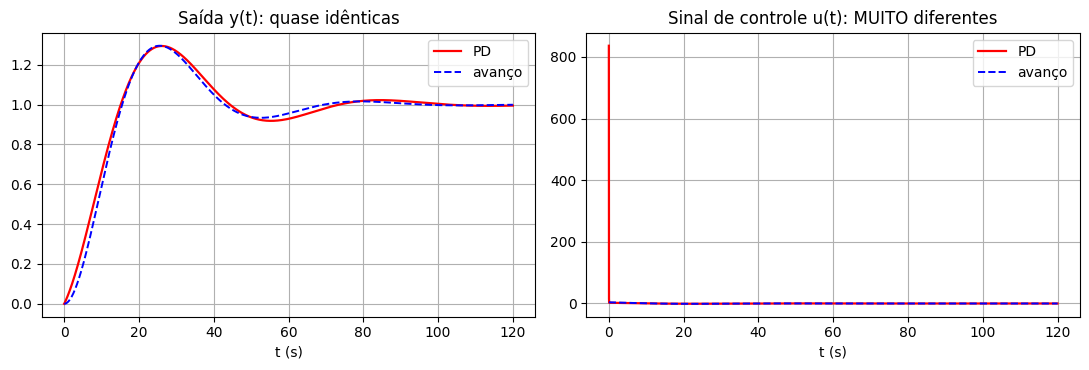

In [2]:
G = ct.tf([0.005], [1, 0.05, 0])
Cpd = ct.tf([7.6, 2.7], [1/110, 1])
Cav = 2.1*ct.tf([12, 1], [6.5, 1])

w = np.logspace(-4, 3, 5000)
for nome, C in [('PD', Cpd), ('avanço', Cav)]:
    mc, pc = mp(C*G, w)
    mdb = 20*np.log10(mc)
    iwc = np.argmin(np.abs(mdb))
    r = medir(mf(C*G), np.linspace(0, 120, 60000))
    print(f'{nome}: ωc = {w[iwc]:.3f}, PM = {pc[iwc]+180:.1f}° | sim: Mp = {r["Mp"]:.1f}%, tr = {r["tr"]:.1f} s')

# sinais de controle: U/R = C/(1+CG)
t = np.linspace(0, 120, 60000)
Upd = ct.feedback(Cpd, G); Uav = ct.feedback(Cav, G)
tt, upd = step(Upd, t); _, uav = step(Uav, t)
print(f'\nPICO DO SINAL DE CONTROLE:  PD = {upd.max():.1f}   vs   avanço = {uav.max():.2f}')
print(f'razão = {upd.max()/uav.max():.0f}× — o PD exige {upd.max()/uav.max():.0f} vezes mais do atuador!')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
_, ypd = step(mf(Cpd*G), t); _, yav = step(mf(Cav*G), t)
axes[0].plot(tt, ypd, 'r', lw=1.6, label='PD'); axes[0].plot(tt, yav, 'b--', lw=1.4, label='avanço')
axes[0].set_title('Saída y(t): quase idênticas'); axes[0].set_xlabel('t (s)'); axes[0].legend()
axes[1].plot(tt, upd, 'r', lw=1.6, label='PD'); axes[1].plot(tt, uav, 'b--', lw=1.4, label='avanço')
axes[1].set_title('Sinal de controle u(t): MUITO diferentes'); axes[1].set_xlabel('t (s)'); axes[1].legend()
plt.tight_layout(); plt.show()

### ✏️ Responda no relatório

**Q1.1** PD e avanço entregaram praticamente a mesma saída. Por que, então, o sinal de controle do PD é $\approx 200$ vezes maior? (Dica: o que o termo $k_d\,s$ faz com o degrau de referência em $t = 0$?)

**Q1.2** Qual a consequência prática disso num motor real? Que fenômeno **não linear** apareceria (ponte para o Módulo 04)?

**Q1.3** O polo de filtragem em $-100\,\omega_c$ custa $-0{,}6°$ de fase. Por que não colocá-lo em $-\omega_c$?

## Parte 2 — PI: erro à rampa zero e o preço na PM

A planta já é tipo 1 (erro ao degrau nulo), então o PI é usado aqui para zerar o **erro à rampa** (malha vira tipo 2): $C_{PI}(s) = \dfrac{s+0{,}018}{s}$ — zero em $-0{,}018$, bem abaixo da banda da malha ($\omega_c \approx 0{,}06$ rad/s).

> ⚠️ **Atenção:** PI **puro, sem reajuste de ganho**, cobra pedágio na margem de fase — observe o overshoot e responda a Q2.3. Na prática o PI raramente anda sozinho: ou o ganho é reprojetado, ou ele vira o "I" de um PID (Parte 3).

malha com PI: ωc = 0.064 rad/s,  PM = 22.3°  (sem PI: PM = 38,6°)


erro à rampa em t = 400 s:  sem PI = 10.00  (teoria: 1/kv = 1/0,1 = 10),  com PI = 0.0165 → 0 ✓


degrau com PI: y(400 s) = 0.9973,  Mp = 61.7%


a resposta atinge 0,9 só em t = 24 s — a cauda lenta do integrador


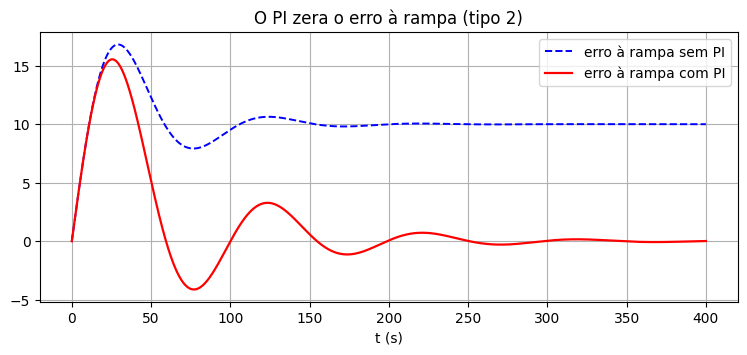

In [3]:
G = ct.tf([0.005], [1, 0.05, 0])
Cpi = ct.tf([1, 0.018], [1, 0])

w = np.logspace(-4, 3, 5000)
mc, pc = mp(Cpi*G, w)
mdb = 20*np.log10(mc); iwc = np.argmin(np.abs(mdb))
print(f'malha com PI: ωc = {w[iwc]:.3f} rad/s,  PM = {pc[iwc]+180:.1f}°  (sem PI: PM = 38,6°)')

t = np.linspace(0, 400, 80000)
# erro à rampa: e/r = 1/(1+CG); rampa u = t
E0 = ct.feedback(1, G)          # sem PI (tipo 1: erro à rampa = 1/kv)
E1 = ct.feedback(1, Cpi*G)      # com PI (tipo 2: erro à rampa = 0)
r0 = ct.forced_response(E0, t, t); e0 = np.asarray(r0.outputs)
r1 = ct.forced_response(E1, t, t); e1 = np.asarray(r1.outputs)
print(f'erro à rampa em t = 400 s:  sem PI = {e0[-1]:.2f}  (teoria: 1/kv = 1/0,1 = 10),  com PI = {e1[-1]:.4f} → 0 ✓')

# degrau com PI: cauda lenta do integrador
r = medir(mf(Cpi*G), t)
print(f'degrau com PI: y(400 s) = {r["yss"]:.4f},  Mp = {r["Mp"]:.1f}%')
tt, y = step(mf(Cpi*G), t)
i90 = np.argmax(y >= 0.9)
print(f'a resposta atinge 0,9 só em t = {tt[i90]:.0f} s — a cauda lenta do integrador')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(tt, e0, 'b--', lw=1.4, label='erro à rampa sem PI')
ax.plot(tt, e1, 'r', lw=1.6, label='erro à rampa com PI')
ax.set_xlabel('t (s)'); ax.legend(); ax.set_title('O PI zera o erro à rampa (tipo 2)')
plt.show()

### ✏️ Responda no relatório

**Q2.1** Explique pelo teorema do valor final por que o erro à rampa zera com o PI.

**Q2.2** O zero do PI em $-0{,}018$ cria um modo lento $\approx e^{-0{,}018t}$. Estime a constante de tempo dessa cauda e compare com o que você mediu.

**Q2.3** A PM caiu de $38{,}6°$ para $\approx 22°$ — e o overshoot subiu de $30\,\%$ para $\approx 62\,\%$. Mostre a conta: qual a contribuição de fase do PI em $\omega_c = 0{,}064$ rad/s? Que duas providências de projeto resolveriam isso?

## Parte 3 — PID completo: PD × PI

**Problema (âncora §3.5.3):** $G(s) = \dfrac{0{,}01}{(s+0{,}05)(s+0{,}07)}$. Requisitos: $M_p \leq 20\,\%$, $t_r \leq 12$ s, $e_{ss} = 0$.

**Receita:** PD para a dinâmica (PM alvo $= 65°$ em $\omega_c = 0{,}18$ rad/s — a folga paga a PI) × PI para o erro (zero em $-\omega_c/10$).

In [4]:
G = ct.tf([0.01], [1, 0.12, 0.0035])
wc_alvo = 0.18

# --- PD ---
m, p = mp(G, wc_alvo)
PM_atual = p[0] + 180
phi = 65 - PM_atual
kp = math.cos(math.radians(phi))/m[0]
kd = math.sin(math.radians(phi))/(wc_alvo*m[0])
print(f'em ωc = {wc_alvo}: |G| = {m[0]:.4f} ({20*np.log10(m[0]):.1f} dB), fase = {p[0]:.1f}° → PM atual = {PM_atual:.1f}°')
print(f'φ = {phi:.1f}°  →  kp = {kp:.1f},  kd = {kd:.1f},  polo de filtragem em -{1000*wc_alvo:.0f}')
Cpd = ct.tf([9.5, 3.2], [1/180, 1])      # valores do projeto (arredondados)

# --- PI ---
Cpi = ct.tf([1, 0.018], [1, 0])          # zero em -ωc/10

Cpid = Cpd*Cpi
print('\nC(s) = Cpd × Cpi ='); print(Cpid)

t = np.linspace(0, 120, 120000)
r = medir(mf(Cpid*G), t)
print(f'simulação: Mp = {r["Mp"]:.1f}% (≤ 20% ✓),  tr = {r["tr"]:.1f} s (≤ 12 s ✓),  y(120 s) = {r["yss"]:.4f} → ess → 0 ✓')

mc, pc = mp(Cpid*G, np.logspace(-4, 3, 5000))
mdb = 20*np.log10(mc); iwc = np.argmin(np.abs(mdb))
w = np.logspace(-4, 3, 5000)
print(f'PM compensada = {pc[iwc]+180:.1f}°  (alvo 65°, PI e polo de filtragem custaram ~{(65-(pc[iwc]+180)):.0f}°)')

em ωc = 0.18: |G| = 0.2772 (-11.1 dB), fase = -143.2° → PM atual = 36.8°
φ = 28.2°  →  kp = 3.2,  kd = 9.5,  polo de filtragem em -180

C(s) = Cpd × Cpi =
<TransferFunction>: sys[52]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  9.5 s^2 + 3.371 s + 0.0576
  --------------------------
       0.005556 s^2 + s


simulação: Mp = 12.0% (≤ 20% ✓),  tr = 10.9 s (≤ 12 s ✓),  y(120 s) = 0.9926 → ess → 0 ✓
PM compensada = 59.1°  (alvo 65°, PI e polo de filtragem custaram ~6°)


### ✏️ Responda no relatório

**Q3.1** Refaça na mão as contas de $k_p$ e $k_d$ — os valores arredondados ($k_p = 3{,}2$, $k_d = 9{,}5$) estão coerentes?

**Q3.2** Por que a PM alvo foi $65°$ e não $45$–$50°$? Detalhe de onde sai cada "pedaço" da folga.

**Q3.3** Escreva $C(s)$ na forma PID paralela $K_p + K_d s + K_I/s$ e identifique os três ganhos. (Dica: expanda o produto.)

## Parte 4 — Síntese: os três controladores na carta de Nichols-Black

Fechamento visual do módulo: a planta do PID na carta, e como cada controlador **remodela** a curva (compare com a figura `m3_fig36`).

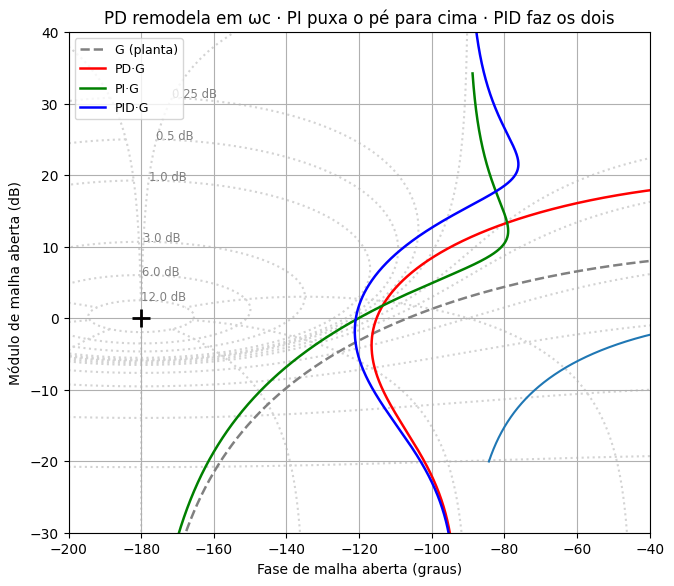

Leitura: o PD move a região de ωc para longe de -180° (PM);
o PI levanta o ganho em baixa frequência (erro → 0);
o PID herda os dois efeitos.


In [5]:
G = ct.tf([0.01], [1, 0.12, 0.0035])
Cpd = ct.tf([9.5, 3.2], [1/180, 1])
Cpi = ct.tf([1, 0.018], [1, 0])
w = np.logspace(-3, 2, 3000)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
carta_nb(ax, xlim=(-200, -40), ylim=(-30, 40))
for nome, L, cor, ls in [('G (planta)', G, 'gray', '--'),
                          ('PD·G', Cpd*G, 'r', '-'),
                          ('PI·G', Cpi*G, 'g', '-'),
                          ('PID·G', Cpd*Cpi*G, 'b', '-')]:
    pw, mdb = nb_curve(L, w)
    ax.plot(pw, mdb, cor, ls=ls, lw=1.8, label=nome)
ax.plot(-180, 0, 'k+', ms=13, mew=2)
ax.legend(loc='upper left', fontsize=9)
ax.set_title('PD remodela em ωc · PI puxa o pé para cima · PID faz os dois')
plt.show()
print('Leitura: o PD move a região de ωc para longe de -180° (PM);')
print('o PI levanta o ganho em baixa frequência (erro → 0);')
print('o PID herda os dois efeitos.')

### ✏️ Responda no relatório

**Q4.1** Identifique na carta onde cada controlador atua (baixa × alta frequência).

**Q4.2** A curva do PID cruza 0 dB com que fase? Qual a PM resultante?

---

## Encerramento do módulo

Você completou o projeto na frequência: **PD** (dinâmica), **PI** (regime), **PID** (os dois), tudo verificado por simulação e sintetizado na carta. No **Módulo 04** a hipótese de linearidade cai: saturação (lembra do pico de controle do PD no Lab 14 Parte 1?), zona morta, histerese e funções descritivas.